# Rejection Sampling example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(3)

## Example: Sampling a Gaussian
Let's sample a simple unit Gaussian, $\mathcal{N}(0, 1)$, using rejection sampling.

The unnormalized $p(x)$ can be written as: 
$$\tilde{p}(x) = \exp(-x^2/2)$$

In [2]:
def tilde_p(x): 
    return np.exp(-x**2/2)

We can select a uniform distribution over [-5, 5] as the proposal
$$M q(x) = 1\quad{\rm if} -5 < x < 5$$ which satisfies $M q(x) \ge \tilde{p}(x)$ and is easy to sample.

The first step of rejection sampling is to sample $x' \sim q(x)$ and $u \sim \mathcal{U}(0,1)$

In [3]:
x = 10*np.random.uniform() - 5 # x sampled uniformly from -3 to 3
u = np.random.uniform()

if $u > \frac{\tilde{p}(x')}{Mq(x')}$ reject; else accept

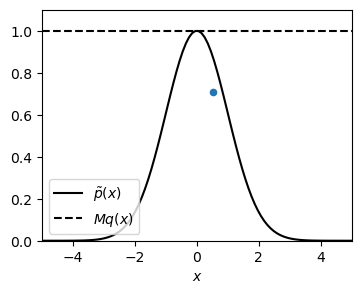

In [4]:
plt.figure(figsize=(4,3))
if (u > tilde_p(x) / 1.): # reject
    plt.scatter(x, u, c='C1', s=20)
else: 
    plt.scatter(x, u, c='C0', s=20)
plt.plot(np.linspace(-5, 5, 100), tilde_p(np.linspace(-5, 5, 100)), label=r'$\tilde{p}(x)$', c='k', linestyle='-')
plt.plot(np.linspace(-5, 5, 100), np.ones(100), label='$M q(x)$', c='k', linestyle='--')
plt.xlabel('$x$')
plt.xlim(-5, 5)
plt.ylim(0., 1.1)
plt.legend(loc='lower left'); plt.show()

first sample is accepted

In [5]:
x = 10*np.random.uniform() - 5 # x sampled uniformly from -3 to 3
u = np.random.uniform()

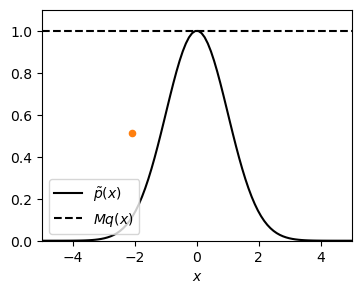

In [6]:
plt.figure(figsize=(4,3))
if (u > tilde_p(x) / 1.): # reject
    plt.scatter(x, u, c='C1', s=20)
else: 
    plt.scatter(x, u, c='C0', s=20)
plt.plot(np.linspace(-5, 5, 100), tilde_p(np.linspace(-5, 5, 100)), label=r'$\tilde{p}(x)$', c='k', linestyle='-')
plt.plot(np.linspace(-5, 5, 100), np.ones(100), label='$M q(x)$', c='k', linestyle='--')
plt.xlabel('$x$')
plt.xlim(-5, 5)
plt.ylim(0., 1.1)
plt.legend(loc='lower left'); plt.show()

while the second sample is rejected. If we repeat this process $S$ times

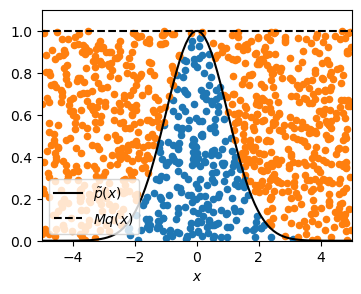

In [7]:
plt.figure(figsize=(4,3))

S = 1000
for i in range(S): 
    x = 10*np.random.uniform() - 5 # x sampled uniformly from -3 to 3
    u = np.random.uniform()
    
    if (u > tilde_p(x) / 1.): # reject
        plt.scatter(x, u, c='C1', s=20)
    else: 
        plt.scatter(x, u, c='C0', s=20)
        
plt.plot(np.linspace(-5, 5, 100), tilde_p(np.linspace(-5, 5, 100)), label=r'$\tilde{p}(x)$', c='k', linestyle='-')
plt.plot(np.linspace(-5, 5, 100), np.ones(100), label='$M q(x)$', c='k', linestyle='--')
plt.xlabel('$x$'); plt.xlim(-5, 5); plt.ylim(0., 1.1); plt.legend(loc='lower left'); plt.show()

Lets scale it up

In [8]:
S = 100000 # S sample
x = 10*np.random.uniform(size=S) - 5
u = np.random.uniform(size=S)

reject = (u > tilde_p(x) / 1.)
accept = ~reject

samples = x[accept]

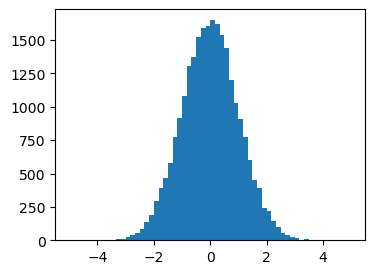

In [9]:
plt.figure(figsize=(4,3))
plt.hist(samples, range=(-5, 5), bins=60)
plt.show()